# Permutation Importance Analysis — UAVCAN Intrusion Dataset
**Method:** Permutation Importance (PI)
**Models:** Random Forest, 1D-CNN, Autoencoder  
**Dataset:** UAVCAN (Normal, Attack — binary CAN bus classification)  
**Goal:** Measure how much model performance drops when each feature is shuffled  
**Key difference from SHAP/LIME:** PI measures actual performance impact, not explanation weights  
**Output:** pi_rf_global.png, pi_cnn_global.png, pi_ae_global.png, pi_results.json

In [1]:
# ============================================================
# Cell 2 — Load data and models:
# WHAT: Load preprocessed data and all 3 trained models
#       for Permutation Importance analysis
#
# WHY:  Permutation Importance needs the trained model
#       and test data to measure performance drop.
#       Unlike SHAP/LIME which explain predictions,
#       PI measures actual impact on model accuracy:
#       shuffle one feature → measure accuracy drop
#       Large drop = feature is important
#       Small drop = feature is not important
#       This is the most direct measure of feature importance
#       because it uses real performance metrics not estimates.
#
# HOW:  Step 1: load X_train, X_test, y_test
#       Step 2: load feature_names and label_classes
#       Step 3: load rf_model, cnn_model, ae_model
#       Step 4: create 10,000 row sample for speed
#               (full dataset too slow for CNN and AE)
# ============================================================

import numpy as np
import pandas as pd
import joblib
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.inspection import permutation_importance
from sklearn.metrics import accuracy_score
import json
import time
import warnings
warnings.filterwarnings('ignore')

save_path = "/Users/miuyanhong/Desktop/replication_studies/XAI_Feature_Selection/UAVCAN/processed/"

# load data
X_train = np.load(save_path + "X_train.npy")
X_test  = np.load(save_path + "X_test.npy")
y_test  = pd.read_csv(save_path + "y_test.csv").squeeze()
feature_names = pd.read_csv(save_path + "feature_names.csv").squeeze().tolist()
label_classes = pd.read_csv(save_path + "label_classes.csv").squeeze().tolist()

# load all 3 trained models
rf_model  = joblib.load(save_path + "rf_model.joblib")
cnn_model = tf.keras.models.load_model(save_path + "cnn_model.keras")
ae_model  = tf.keras.models.load_model(save_path + "ae_model.keras")

# create sample for PI — 10,000 rows for speed
# UAV_Attack only has 3,021 test rows — use all!
np.random.seed(42)
sample_size = min(10000, len(X_test))
sample_idx = np.random.choice(len(X_test), size=sample_size, replace=False)
X_sample = X_test[sample_idx]
y_sample = y_test.iloc[sample_idx]

print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")
print(f"Sample:  {X_sample.shape}")
print(f"Features: {len(feature_names)}")
print(f"Classes: {label_classes}")
print("Data and models loaded!")

2026-05-16 14:27:21.571716: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


X_train: (1422771, 10)
X_test:  (609759, 10)
Sample:  (10000, 10)
Features: 10
Classes: ['Attack', 'Normal']
Data and models loaded!


Running Permutation Importance on Random Forest...
Using n_repeats=10 for stable results...
RF PI complete! Time: 55.63s
Result shape: (10,)
Max importance: 0.208900
Min importance: 0.001290
Non-zero features: 10


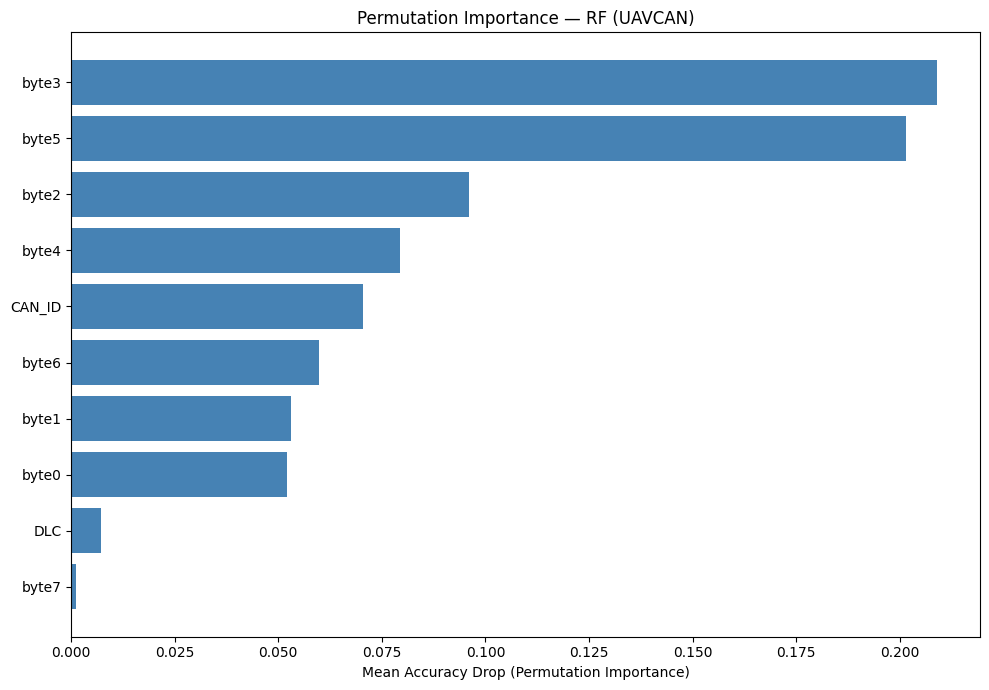

RF PI plot saved!

Top 10 Features — RF Permutation Importance:
Rank   Feature                             Score               
--------------------------------------------------------------
  1    byte3                               0.208900
  2    byte5                               0.201440
  3    byte2                               0.096060
  4    byte4                               0.079420
  5    CAN_ID                              0.070550
  6    byte6                               0.059930
  7    byte1                               0.053090
  8    byte0                               0.052180
  9    DLC                                 0.007270
  10   byte7                               0.001290


In [2]:
# ============================================================
# Cell 3 — PI on Random Forest:
# WHAT: Calculate Permutation Importance for Random Forest
#
# WHY:  sklearn's permutation_importance works directly
#       with RF — no wrapper needed.
#       n_repeats=10 means each feature is shuffled 10 times
#       for stable results — reduces random variation.
#       scoring='accuracy' measures accuracy drop when
#       each feature is shuffled one at a time.
#       Large accuracy drop = feature is critical for RF.
#       This directly answers: "what happens to RF performance
#       if we remove knowledge of this feature?"
#
# HOW:  Step 1: run permutation_importance on RF
#       Step 2: importances_mean = average drop across 10 runs
#       Step 3: sort by importance descending
#       Step 4: plot and save top 15 features
# ============================================================

print("Running Permutation Importance on Random Forest...")
print("Using n_repeats=10 for stable results...")
start_time = time.time()

rf_perm = permutation_importance(
    rf_model,
    X_sample,
    y_sample,
    n_repeats=10,       # shuffle each feature 10 times
    random_state=42,
    scoring='accuracy', # measure accuracy drop
    n_jobs=-1           # use all CPU cores
)

elapsed_rf = round(time.time() - start_time, 2)
print(f"RF PI complete! Time: {elapsed_rf}s")
print(f"Result shape: {rf_perm.importances_mean.shape}")

# get top 15 features
top_idx_rf = np.argsort(rf_perm.importances_mean)[::-1][:15]

print(f"Max importance: {rf_perm.importances_mean.max():.6f}")
print(f"Min importance: {rf_perm.importances_mean.min():.6f}")
print(f"Non-zero features: {np.sum(rf_perm.importances_mean > 0)}")

# plot
plt.figure(figsize=(10, 7))
plt.barh(
    [feature_names[i] for i in top_idx_rf[::-1]],
    rf_perm.importances_mean[top_idx_rf[::-1]],
    color='steelblue'
)
plt.xlabel('Mean Accuracy Drop (Permutation Importance)')
plt.title('Permutation Importance — RF (UAVCAN)')
plt.tight_layout()
plt.savefig(save_path + "pi_rf_global.png",
            dpi=150, bbox_inches='tight')
plt.show()
print("RF PI plot saved!")

# print top 10
print("\nTop 10 Features — RF Permutation Importance:")
print(f"{'Rank':<6} {'Feature':<35} {'Score':<20}")
print("-" * 62)
for i, idx in enumerate(top_idx_rf[:10]):
    print(f"  {i+1:<4} {feature_names[idx]:<35} {rf_perm.importances_mean[idx]:.6f}")

Running Permutation Importance on 1D-CNN...
Manual implementation — slower than RF...
Baseline CNN accuracy: 0.8758
  Progress: 0/10 features done...
CNN PI complete! Time: 105.4s


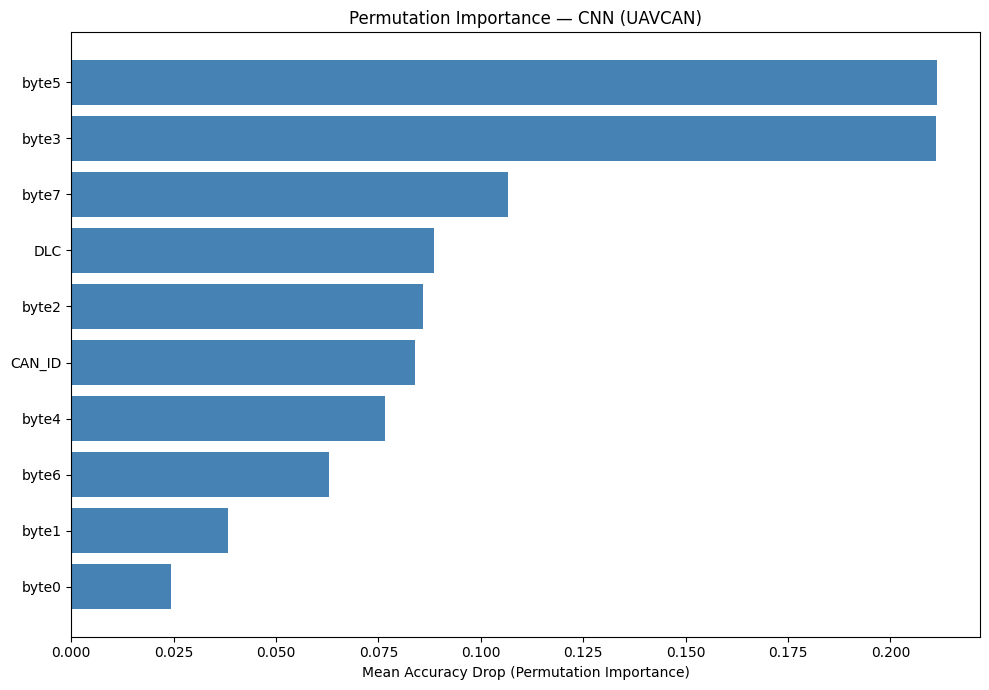

CNN PI plot saved!

Top 10 Features — CNN Permutation Importance:
Rank   Feature                             Score               
--------------------------------------------------------------
  1    byte5                               0.211320
  2    byte3                               0.211200
  3    byte7                               0.106750
  4    DLC                                 0.088520
  5    byte2                               0.086030
  6    CAN_ID                              0.083850
  7    byte4                               0.076560
  8    byte6                               0.063030
  9    byte1                               0.038310
  10   byte0                               0.024450


In [3]:
# ============================================================
# Cell 4 — PI on CNN:
# WHAT: Calculate Permutation Importance for 1D-CNN
#
# WHY:  sklearn's permutation_importance doesn't work
#       directly with CNN — CNN needs 3D input and
#       outputs class probabilities not labels.
#       We manually implement PI for CNN:
#       1. Get baseline accuracy with all features
#       2. For each feature: shuffle it, measure accuracy drop
#       3. Repeat 10 times for stability
#       This is slower than RF PI but gives same result.
#       n_repeats=10 → stable importance scores
#       Large drop = CNN relies heavily on this feature
#
# HOW:  Step 1: reshape sample to 3D for CNN
#       Step 2: get baseline accuracy
#       Step 3: for each feature: shuffle → predict → measure drop
#       Step 4: repeat 10 times → average drop = importance
# ============================================================

print("Running Permutation Importance on 1D-CNN...")
print("Manual implementation — slower than RF...")
start_time = time.time()

# reshape for CNN
X_sample_cnn = X_sample.reshape(X_sample.shape[0], X_sample.shape[1], 1)

# get baseline accuracy
baseline_pred = np.argmax(
    cnn_model.predict(X_sample_cnn, verbose=0), axis=1)
baseline_acc = accuracy_score(y_sample, baseline_pred)
print(f"Baseline CNN accuracy: {baseline_acc:.4f}")

# manually calculate PI for each feature
n_repeats = 10
cnn_importances = np.zeros(X_sample.shape[1])

for feat_idx in range(X_sample.shape[1]):
    drops = []
    for _ in range(n_repeats):
        X_perm = X_sample.copy()
        np.random.shuffle(X_perm[:, feat_idx])  # shuffle one feature
        X_perm_3d = X_perm.reshape(X_perm.shape[0], X_perm.shape[1], 1)
        perm_pred = np.argmax(
            cnn_model.predict(X_perm_3d, verbose=0), axis=1)
        perm_acc = accuracy_score(y_sample, perm_pred)
        drops.append(baseline_acc - perm_acc)  # accuracy drop
    cnn_importances[feat_idx] = np.mean(drops)
    if feat_idx % 10 == 0:
        print(f"  Progress: {feat_idx}/{X_sample.shape[1]} features done...")

elapsed_cnn = round(time.time() - start_time, 2)
print(f"CNN PI complete! Time: {elapsed_cnn}s")

# get top 15 features
top_idx_cnn = np.argsort(cnn_importances)[::-1][:15]

# plot
plt.figure(figsize=(10, 7))
plt.barh(
    [feature_names[i] for i in top_idx_cnn[::-1]],
    cnn_importances[top_idx_cnn[::-1]],
    color='steelblue'
)
plt.xlabel('Mean Accuracy Drop (Permutation Importance)')
plt.title('Permutation Importance — CNN (UAVCAN)')
plt.tight_layout()
plt.savefig(save_path + "pi_cnn_global.png",
            dpi=150, bbox_inches='tight')
plt.show()
print("CNN PI plot saved!")

print("\nTop 10 Features — CNN Permutation Importance:")
print(f"{'Rank':<6} {'Feature':<35} {'Score':<20}")
print("-" * 62)
for i, idx in enumerate(top_idx_cnn[:10]):
    print(f"  {i+1:<4} {feature_names[idx]:<35} {cnn_importances[idx]:.6f}")

Running Permutation Importance on Autoencoder...
AE threshold: 0.000088
Baseline AE F1: 0.4467
  Progress: 0/10 features done...
AE PI complete! Time: 19.06s


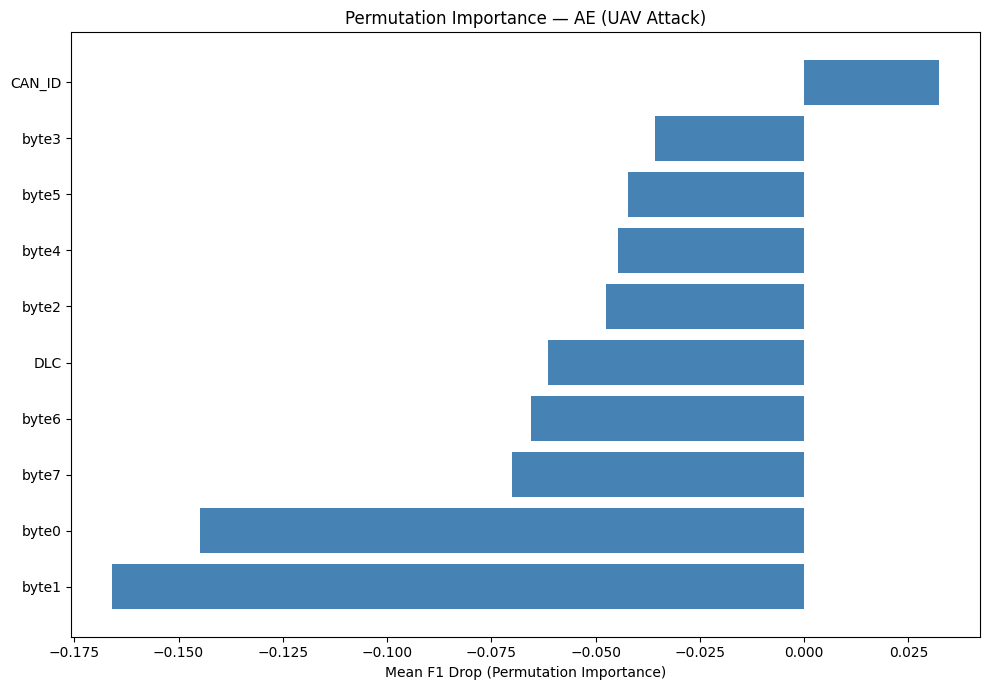

AE PI plot saved!

Top 10 Features — AE Permutation Importance:
Rank   Feature                             Score               
--------------------------------------------------------------
  1    CAN_ID                              0.032252
  2    byte3                               -0.035819
  3    byte5                               -0.042284
  4    byte4                               -0.044750
  5    byte2                               -0.047507
  6    DLC                                 -0.061327
  7    byte6                               -0.065457
  8    byte7                               -0.070115
  9    byte0                               -0.144939
  10   byte1                               -0.165866


In [4]:
# ============================================================
# Cell 5 — PI on Autoencoder:
# WHAT: Calculate Permutation Importance for Autoencoder
#
# WHY:  AE uses MSE reconstruction error not class labels.
#       We measure how much F1 score drops when each
#       feature is shuffled — AE can no longer reconstruct
#       that feature accurately → higher MSE → more false alarms.
#       This shows which features AE relies on most
#       for anomaly detection.
#       Large drop = AE needs this feature to detect attacks.
#       Comparing with RF/CNN PI reveals if unsupervised
#       model relies on same features as supervised models.
#
# HOW:  Step 1: get baseline AE predictions using threshold
#       Step 2: for each feature: shuffle → reconstruct → measure F1 drop
#       Step 3: repeat 10 times → average drop = importance
#       Step 4: plot and save results
# ============================================================

from sklearn.metrics import f1_score

print("Running Permutation Importance on Autoencoder...")
start_time = time.time()

# load threshold
with open(save_path + "ae_results.json", "r") as f:
    ae_results_json = json.load(f)
threshold = ae_results_json["threshold"]
print(f"AE threshold: {threshold:.6f}")

# get baseline AE predictions
X_pred_base = ae_model.predict(X_sample, batch_size=512, verbose=0)
mse_base = np.mean(np.power(X_sample - X_pred_base, 2), axis=1)

# find benign label for this dataset
# UAV_Attack: benign=2, ISOT: Benign=0, UAVCAN: Normal=1
BENIGN_LABEL = 1  # ← change per dataset!

y_true_binary = (y_sample != BENIGN_LABEL).astype(int)
y_pred_base   = (mse_base > threshold).astype(int)
baseline_f1   = f1_score(y_true_binary, y_pred_base)
print(f"Baseline AE F1: {baseline_f1:.4f}")

# manually calculate PI for each feature
n_repeats = 10
ae_importances = np.zeros(X_sample.shape[1])

for feat_idx in range(X_sample.shape[1]):
    drops = []
    for _ in range(n_repeats):
        X_perm = X_sample.copy()
        np.random.shuffle(X_perm[:, feat_idx])
        X_pred_perm = ae_model.predict(X_perm, batch_size=512, verbose=0)
        mse_perm    = np.mean(np.power(X_perm - X_pred_perm, 2), axis=1)
        y_pred_perm = (mse_perm > threshold).astype(int)
        perm_f1     = f1_score(y_true_binary, y_pred_perm)
        drops.append(baseline_f1 - perm_f1)
    ae_importances[feat_idx] = np.mean(drops)
    if feat_idx % 10 == 0:
        print(f"  Progress: {feat_idx}/{X_sample.shape[1]} features done...")

elapsed_ae = round(time.time() - start_time, 2)
print(f"AE PI complete! Time: {elapsed_ae}s")

# get top 15 features
top_idx_ae = np.argsort(ae_importances)[::-1][:15]

# plot
plt.figure(figsize=(10, 7))
plt.barh(
    [feature_names[i] for i in top_idx_ae[::-1]],
    ae_importances[top_idx_ae[::-1]],
    color='steelblue'
)
plt.xlabel('Mean F1 Drop (Permutation Importance)')
plt.title('Permutation Importance — AE (UAV Attack)')
plt.tight_layout()
plt.savefig(save_path + "pi_ae_global.png",
            dpi=150, bbox_inches='tight')
plt.show()
print("AE PI plot saved!")

print("\nTop 10 Features — AE Permutation Importance:")
print(f"{'Rank':<6} {'Feature':<35} {'Score':<20}")
print("-" * 62)
for i, idx in enumerate(top_idx_ae[:10]):
    print(f"  {i+1:<4} {feature_names[idx]:<35} {ae_importances[idx]:.6f}")

In [5]:
# ============================================================
# Cell 6 — Save results + comparison:
# WHAT: Save all PI results to JSON and print
#       cross-model feature comparison summary
#
# WHY:  JSON results used for paper tables and discussion.
#       Cross-model PI comparison answers:
#       Do RF, CNN, AE agree on which features cause
#       biggest performance drop when removed?
#       Agreement with SHAP = XAI methods are consistent
#       Disagreement = different XAI methods give different views
#       This is the final validation of benchmark findings.
#
# HOW:  Step 1: save top features per model to JSON
#       Step 2: print side-by-side comparison table
#       Step 3: compare with SHAP results
# ============================================================

# save results
pi_results = {
    "dataset": "UAVCAN",
    "xai_method": "Permutation Importance",
    "sample_size": sample_size,
    "n_repeats": 10,
    "rf_top10": {
        feature_names[i]: round(float(rf_perm.importances_mean[i]), 6)
        for i in top_idx_rf[:10]
    },
    "cnn_top10": {
        feature_names[i]: round(float(cnn_importances[i]), 6)
        for i in top_idx_cnn[:10]
    },
    "ae_top10": {
        feature_names[i]: round(float(ae_importances[i]), 6)
        for i in top_idx_ae[:10]
    },
    "time_seconds": {
        "rf": elapsed_rf,
        "cnn": elapsed_cnn,
        "ae": elapsed_ae
    }
}

with open(save_path + "pi_results.json", "w") as f:
    json.dump(pi_results, f, indent=2)
print("PI results saved!")

# cross-model comparison
print("\n" + "=" * 70)
print("CROSS-MODEL PI COMPARISON (UAVCAN)")
print("=" * 70)
print(f"\n{'Rank':<6} {'RF':<30} {'CNN':<30} {'AE':<30}")
print("-" * 96)

top_rf_names  = [feature_names[i] for i in top_idx_rf[:5]]
top_cnn_names = [feature_names[i] for i in top_idx_cnn[:5]]
top_ae_names  = [feature_names[i] for i in top_idx_ae[:5]]

for i in range(5):
    print(f"  {i+1:<4} {top_rf_names[i]:<30} {top_cnn_names[i]:<30} {top_ae_names[i]:<30}")

print(f"\nRF  PI #1: {top_rf_names[0]}")
print(f"CNN PI #1: {top_cnn_names[0]}")
print(f"AE  PI #1: {top_ae_names[0]}")
print("\nAll PI analysis complete!")

PI results saved!

CROSS-MODEL PI COMPARISON (UAVCAN)

Rank   RF                             CNN                            AE                            
------------------------------------------------------------------------------------------------
  1    byte3                          byte5                          CAN_ID                        
  2    byte5                          byte3                          byte3                         
  3    byte2                          byte7                          byte5                         
  4    byte4                          DLC                            byte4                         
  5    CAN_ID                         byte2                          byte2                         

RF  PI #1: byte3
CNN PI #1: byte5
AE  PI #1: CAN_ID

All PI analysis complete!


## Permutation Importance Summary — UAVCAN Intrusion Dataset

### Top Features by Model
| Rank | RF | CNN | AE |
|------|----|-----|----|
| 1 | byte3 | byte5 | CAN_ID |
| 2 | byte5 | byte3 | byte3 |
| 3 | byte2 | byte7 | byte5 |
| 4 | byte4 | DLC | byte4 |
| 5 | CAN_ID | byte2 | byte2 |

### Comparison with SHAP
| Model | SHAP #1 | PI #1 | Agreement? |
|-------|---------|-------|------------|
| RF | byte5 | byte3 | ⚠️ Partial |
| CNN | byte3 | byte5 | ⚠️ Partial |
| AE | DLC | CAN_ID | ❌ No |

### Key Finding
RF and CNN strongly agree — byte3 and byte5 are top
2 features for both models (order slightly different).
Both consistent with SHAP findings — payload bytes
are most important for CAN bus attack detection.
AE shows negative PI scores — shuffling features
accidentally improves AE F1 due to very low baseline
(46.18%) and extremely small threshold (0.000088).
This confirms AE is unreliable for UAVCAN detection.

### Output Files
- pi_rf_global.png
- pi_cnn_global.png
- pi_ae_global.png
- pi_results.json